In [3]:
using SolidStateDetectors
using Unitful
using Plots; 

In [2]:
sim = Simulation(SSD_examples[:IVCIlayer])
sim.detector = SolidStateDetector(sim.detector, contact_id = 2, contact_potential =500u"V")


________Public Inverted Coax Inactive________

---General Properties---
- Precision type: Float32

	_____Semiconductor_____

Semiconductor{Float32} - High Purity Germanium

# Contacts: 2
Contact 1 - 0.0 V - High Purity Germanium
Contact 2 - 500.0 V - High Purity Germanium

# Passives: 1
Passive Passivation Layer - id -1 - NaN V


In [4]:
typeof(sim)

Simulation{Float32, Cylindrical}

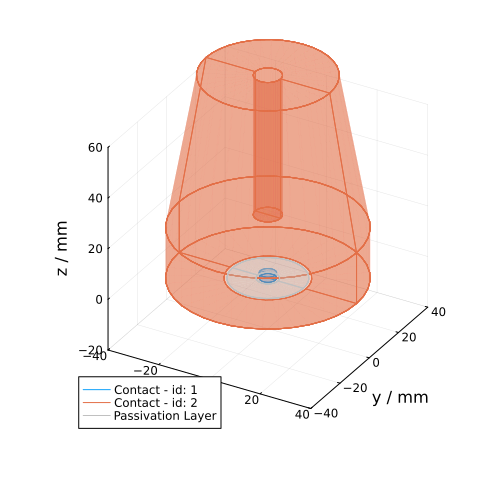

In [5]:
plot(sim.detector, size = (500,500), 
    xunit = u"mm", yunit = u"mm", zunit = u"mm", xlims = (-40,40), ylims = (-40,40), zlims = (-20,60))

In [6]:
grid = Grid(sim)

Grid{Float32, 3, Cylindrical}(0.0 .. 0.04 - length = 24, 0.0 .. 0.0 - length = 1, -0.01 .. 0.09 - length = 20)

In [7]:
calculate_electric_potential!(sim,
        refinement_limits=[0.2, 0.1, 0.05, 0.02],
        verbose=true, #  boolean in the output is produced or not
        depletion_handling=true,  # motiplica epsilon_r per un fattore f nelle regioni non svuotate
        grid=grid)

Simulation: Public Inverted Coax Inactive
Electric Potential Calculation
Bias voltage: 500.0 V
φ symmetry: Detector is φ-symmetric -> 2D computation.
Precision: Float32
Device: CPU
Max. CPU Threads: 1
Coordinate system: Cylindrical
N Refinements: -> 4
Convergence limit: 1.0e-7  => 5.0e-5 V
Initial grid size: (24, 1, 20)

apply initial state : update `sim.electric_potential`, `sim.q_eff_imp`, `sim.q_eff_fix`, `sim.ϵ` and `sim.point_types`
Grid size: (40, 1, 42) - using 1 threads now
Grid size: (72, 1, 84) - using 1 threads now
Grid size: (138, 1, 170) - using 1 threads now
Grid size: (312, 1, 396) - using 1 threads now


┌ Warning: Detector seems not fully depleted...
└ @ SolidStateDetectors /home/ritaferi/Phd/SolidStateDetectors/SolidStateDetectors.jl/src/Simulation/Simulation.jl:1138


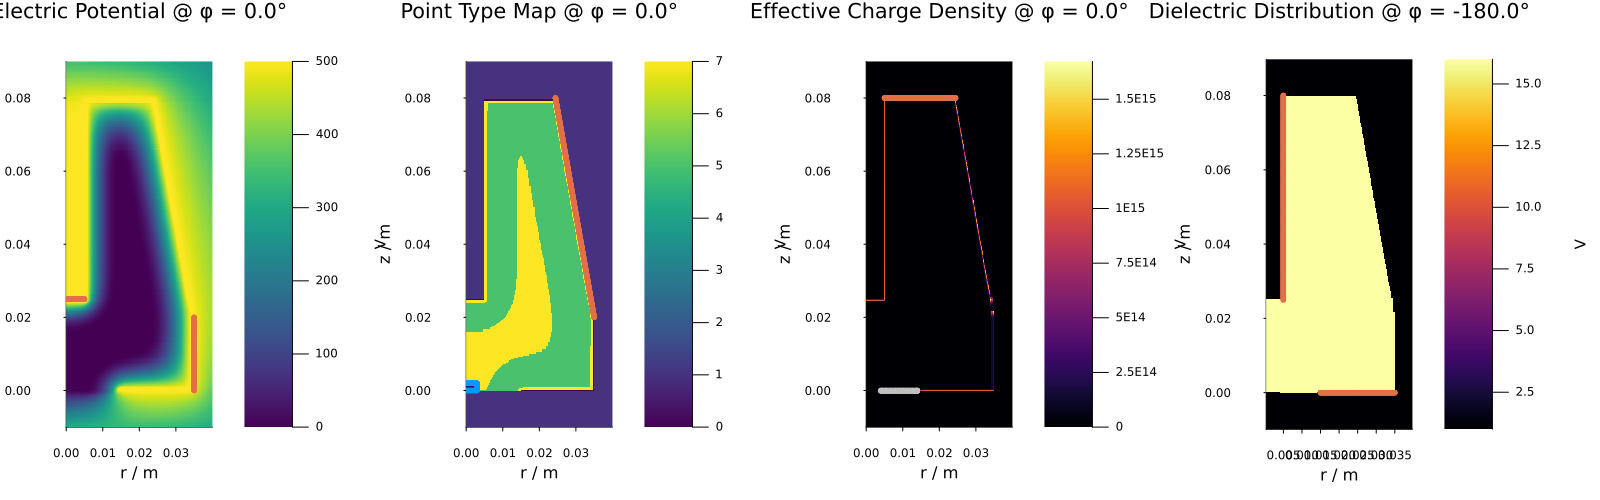

In [8]:
plot(
    plot(sim.electric_potential), # initial electric potential (boundary conditions)
    plot(sim.point_types), # map of different point types: fixed point / inside or outside detector volume / depleted/undepleted
    plot(sim.q_eff_imp), # charge density distribution
    plot(sim.ϵ_r), # dielectric distribution
    layout = (1, 4), size = (1600, 500)
)

plot!(sim.detector, st = :slice, φ = 90u"°", lw = 3, legend = false)

## Weighting potenetial

- ora che ho il campo elettrico, posso vedere cosa accade a $\Phi_\omega$
- L'idea è quella di partire con un valore di max_tick, moltiplicarlo /settare un altro valore iniziale con cui costruire la griglia ed applcare l'initial state, fare poi refinement con questa griglia e riniziare facendo di nuovo ma con una griglia più piccola.
- se però metto una griglia più piccola, devo fare anche interpolazione tra i punti del potenziale cosi da avere la stessa dimensione?

provo ad inzizializzare lo stato con 1 mm

In [9]:
new_grid = Grid(sim, max_tick_distance=1u"mm")

Grid{Float32, 3, Cylindrical}(0.0 .. 0.04 - length = 54, 0.0 .. 0.0 - length = 1, -0.01 .. 0.09 - length = 110)

In [10]:
apply_initial_state!(sim, WeightingPotential, 1, new_grid) # optional


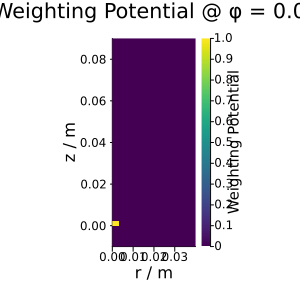

In [11]:
plot(sim.weighting_potentials[1], size = (300, 300) )
#stato iniziale del weighting: eletterodo p setatto a 1  e gli alttri a 0

In [12]:
SolidStateDetectors.update_till_convergence!(sim, WeightingPotential, 1, depletion_handling = true, verbose=true)

8.940697f-7

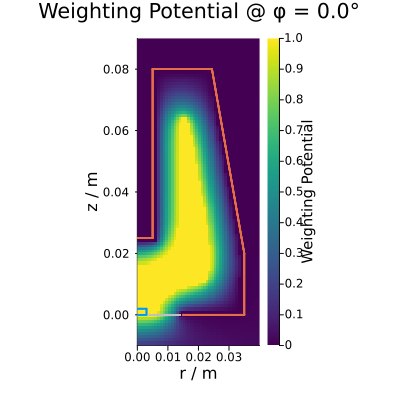

In [13]:
plot(sim.weighting_potentials[1], size = (400, 400) )
plot!(sim.detector, st = :slice, φ = 90u"°",legend = false)

## inizio con il refinement

In [14]:
ref_limits = Float32.(0.2)
max_diff_array = (ref_limits, ref_limits, ref_limits)

(0.2f0, 0.2f0, 0.2f0)

In [15]:

SolidStateDetectors.refine!(sim, WeightingPotential, 1, max_diff_array)

In [16]:
sim.weighting_potentials[1].grid[1]

0.0 .. 0.04 - length = 56

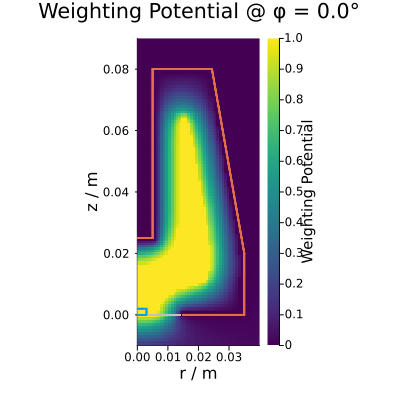

In [17]:
plot(sim.weighting_potentials[1], size = (400, 400) )
plot!(sim.detector, st = :slice, φ = 90u"°",legend = false)

In [18]:
SolidStateDetectors.update_till_convergence!(sim, WeightingPotential, 1, depletion_handling = true, verbose=true)

5.9604645f-7

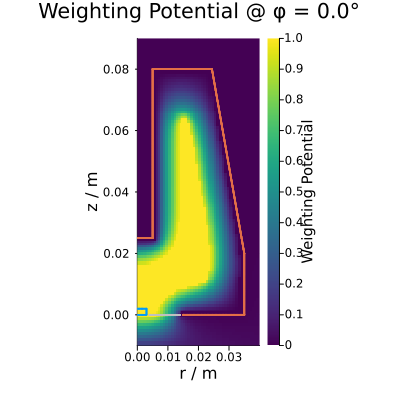

In [19]:
plot(sim.weighting_potentials[1], size = (400, 400) )
plot!(sim.detector, st = :slice, φ = 90u"°",legend = false)

### provo proprio a fare il loop su tutti gli elementi di ref_lim

In [20]:
refinement_limits = Float32.([0.2, 0.1, 0.5, 0.2])
n_refinement_steps = length(refinement_limits)

4

In [21]:
for iref in  1:n_refinement_steps
    println("Refinement step $(refinement_limits[iref]):")
    max_diff_array = (refinement_limits[iref], refinement_limits[iref], refinement_limits[iref])
    SolidStateDetectors.refine!(sim, WeightingPotential, 1, max_diff_array)
    SolidStateDetectors.update_till_convergence!(sim, WeightingPotential, 1, depletion_handling = true, verbose=true)
end

Refinement step 0.2:
Refinement step 0.1:
Refinement step 0.5:
Refinement step 0.2:


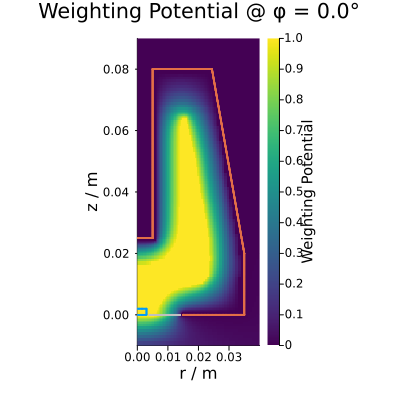

In [22]:
plot(sim.weighting_potentials[1], size = (400, 400) )
plot!(sim.detector, st = :slice, φ = 90u"°",legend = false)

### provo ad applicare il refinement sulla max-tick

In [23]:
new_grid = Grid(sim, max_tick_distance=0.5u"mm")

Grid{Float32, 3, Cylindrical}(0.0 .. 0.04 - length = 94, 0.0 .. 0.0 - length = 1, -0.01 .. 0.09 - length = 210)

In [24]:
d = 0.5u"mm"             # singolo valore con unità
max_tick_distances = ntuple(_ -> Float32(d), 3)  # => (0.5mm::Float32, 0.5mm, 0.5mm)

(0.5f0 mm, 0.5f0 mm, 0.5f0 mm)

In [ ]:
d = 0.5u"mm"
sim.electric_potential =
    SolidStateDetectors.refine_scalar_potential_by_tick_distance(
        sim.weighting_potentials[1],
        (d, d, d)
    )


MethodError: MethodError: no method matching refine_scalar_potential_by_tick_distance(::WeightingPotential{Float32, 3, Cylindrical, Tuple{SolidStateDetectors.DiscreteAxis{Float32, :r0, :infinite, IntervalSets.ClosedInterval{Float32}}, SolidStateDetectors.DiscreteAxis{Float32, :reflecting, :reflecting, IntervalSets.ClosedInterval{Float32}}, SolidStateDetectors.DiscreteAxis{Float32, :infinite, :infinite, IntervalSets.ClosedInterval{Float32}}}}, ::Quantity{Float64, 𝐋, Unitful.FreeUnits{(mm,), 𝐋, nothing}})
The function `refine_scalar_potential_by_tick_distance` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  refine_scalar_potential_by_tick_distance(::Union{DielectricDistribution{T, N, S, AT}, EffectiveChargeDensity{T, N, S, AT}, ElectricPotential{T, N, S, AT}, SolidStateDetectors.ImpurityScale{T, N, S, AT}, PointTypes{T, N, S, AT}, WeightingPotential{T, N, S, AT}} where {N, S, AT}, !Matched::Tuple{T, T, T}; only2d) where T
   @ SolidStat